---
title: Stream data via earthaccess
date: 2026-07-01
github: https://github.com/cryointhecloud/CryocloudWebsite
subject: Tutorial
authors:
  - name: Tasha Snow
    affiliations:
      - University of Maryland
      - NASA Goddard Space Flight Center
      - CSM
    email: tsnow03@umd.edu
    orcid: 0000-0001-5697-5470
    corresponding: true
    github: tsnow03
license: MIT
---

::::{admonition} Acknowledgments
:class: seealso

We thank NASA Openscapes Earth Cloud Cookbook for portions of code and text: \
[https://nasa-openscapes.github.io/earthdata-cloud-cookbook/](https://nasa-openscapes.github.io/earthdata-cloud-cookbook/) 
::::

# Overview

::::{admonition} What you'll learn
:class: tip

By the end of this tutorial, you will be able to:

- Find and stream data from the NASA Earth Cloud directly into memory, using MERRA-2 as an example
- How to inspect basic variables and visualize the data interactively

::::{dropdown} Notes for beginners
:class: hint

“Stream into memory” means you don’t download files permanently—you read them on-the-fly from cloud storage.
::::

::::{dropdown} What you’ll do (quick preview)
- Sign in with **Earthdata Login**  
- Search for a dataset, in this case **MERRA-2**  
- Open results with `earthaccess.open(...)` and inspect a few variables
- **Visualize** multiple rasters across time 
::::

::::{admonition} Prerequisites
:class: important

- An [**Earthdata Login**](https://urs.earthdata.nasa.gov/) (free). If you don’t have one yet, create it first.
::::

::::{admonition} Who is this for?
:class: hint
- **Beginners:** You’ll get a gentle, step-by-step start with cloud data.  
- **Experts:** You can skim to the code and links; advanced **Notes** are flagged along the way.
::::

# Introduction to MERRA-2

In this tutorial, we will open and visualize data from NASA’s **MERRA-2** datasets in the cloud. Keep in mind that we show this for one dataset, but the same approach can be used for all other NASA datasets in the cloud.

# Libraries needed to get started

In [43]:
%matplotlib widget

# For searching and accessing NASA data
import earthaccess

# For reading data, analysis and plotting
import xarray as xr
import pandas as pd

# For accessing the time dimension from filenames
from datetime import datetime
import re

# For plotting found datasets
import ipywidgets as widgets
import matplotlib.pyplot as plt


import pprint  # For nice printing of python objects
import warnings
warnings.filterwarnings("ignore")

# EarthData login

An **Earthdata Login** account is required to access (and in many cases stream) NASA data. If you don’t have one yet, register at <https://urs.earthdata.nasa.gov>. It’s free and quick to set up. We’ll use the `earthaccess` library to authenticate. 

Login requires your Earthdata Login username and password. The `login` method will automatically search for these credentials as environment variables or in a `.netrc` file, and if those aren't available it will prompt you to enter your username and password. We use the prompt strategy here.

In [2]:
auth = earthaccess.login()

# Sanity check so you know that your credentals worked.
assert auth.authenticated, "Earthdata Login failed — please re-try."

# Search for SWOT cloud-native collections

`earthaccess` leverages the Common Metadata Repository (CMR) API to search for collections and granules.  [Earthdata Search](https://search.earthdata.nasa.gov/search) also uses the CMR API.

We can use the `search_datasets` method to search for MERRA-2 collections by setting `keyword="MERRA-2"`. 

::::{dropdown} Advanced search options
The argument passed to `keyword` can be any string and can include wildcard characters `?` or `*`. To see a full list of search parameters you can type `earthaccess.search_datasets?`.  Using `?` after a python object displays the `docstring` for that object.
::::

A count of the number of data collections (Datasets) found is given.

In [3]:
query = earthaccess.search_datasets(
    keyword="MERRA-2",
    cloud_hosted = True
)
print (f'{len(query)} datasets found.')

219 datasets found.


We can get a summary of each dataset, which includes links for where to find lengthier descriptions of the data. We look at the first five in the query here.

In [4]:
for collection in query[10:15]:
    print(collection['umm']['EntryTitle'])
    pprint.pprint(collection.summary(), sort_dicts=True, indent=4)
    print('')  # Add a space between collections for readability

MERRA-2 tavgM_2d_slv_Nx: 2d,Monthly mean,Time-Averaged,Single-Level,Assimilation,Single-Level Diagnostics 0.625 x 0.5 degree V5.12.4 (M2TMNXSLV) at GES DISC
{   'cloud-info': {   'Region': 'us-west-2',
                      'S3BucketAndObjectPrefixNames': [   's3://gesdisc-cumulus-prod-protected/MERRA2_MONTHLY/M2TMNXSLV.5.12.4/'],
                      'S3CredentialsAPIDocumentationURL': 'https://data.gesdisc.earthdata.nasa.gov/s3credentialsREADME',
                      'S3CredentialsAPIEndpoint': 'https://data.gesdisc.earthdata.nasa.gov/s3credentials'},
    'concept-id': 'C1276812859-GES_DISC',
    'file-type': '',
    'get-data': [   'https://goldsmr4.gesdisc.eosdis.nasa.gov/data/MERRA2_MONTHLY/M2TMNXSLV.5.12.4/',
                    'https://search.earthdata.nasa.gov/search/granules?p=C1276812859-GES_DISC'],
    'short-name': 'M2TMNXSLV',
    'version': '5.12.4'}

MERRA-2 tavg1_2d_adg_Nx: 2d,1-Hourly,Time-averaged,Single-Level,Assimilation,Aerosol Diagnostics (extended) 0.625 x 0.5

For each collection, `summary` returns a subset of fields from the collection metadata and Unified Metadata Model (UMM) entry.

- `concept-id` is an unique identifier for the collection that is composed of a alphanumeric code and the provider-id for the DAAC.
- `file-type` gives information about the file format of the collection files.
- `get-data` is a collection of URLs that can be used to access data, dataset landing pages, and tools. 
- `short-name` is the name of the dataset that appears on the dataset set landing page. `ShortNames` are generally how different products are referred to.
- `version` is the version of each collection.
 

For _cloud-hosted_ data, there is additional information about the location of the S3 bucket that holds the data and where to get credentials to access the S3 buckets.  In general, you don't need to worry about this information because `earthaccess` handles S3 credentials for you.  Nevertheless it may be useful for troubleshooting. 

```{note}
In Python, all data are represented by _objects_.  These _objects_ contain both data and methods (think functions) that operate on the data.  `earthaccess` includes  `DataCollection` and `DataGranule` objects that contain data about collections and granules returned by `search_datasets` and `search_data` respectively.  If you are familiar with Python, you will see that the data in each `DataCollection` object is organized as a hierarchy of python dictionaries, lists and strings.  So if you know the dictionary key for the metadata entry you want you can get that metadata using standard dictionary methods.  Take a look at https://github.com/nsidc/earthaccess/blob/main/earthaccess/results.py#L80 to learn more.
```

If you want to see just those short-names so you can paste it into the `earthaccess` data access below, you can use this method:

In [5]:
for collection in query[:5]:
    pprint.pprint(collection.summary()['short-name'], sort_dicts=True, indent=4)

'M2T1NXAER'
'M2T1NXSLV'
'M2I3NPASM'
'M2T1NXFLX'
'M2T1NXRAD'


# Search MERRA-2 data using spatial and temporal filters 

Once, you have identified the dataset you want to work with, you can use the `search_data` method to search a data set with spatial and temporal filters. Since we are using the M2I3NVASM (Assimilated Meteorological Fields) product for this tutorial, we'll search for those rasters over the Bach Ice Shelf in Antarctica, for May 1 and May 2, 2025.

Either `concept-id` or `short-name` can be used to search for granules from a particular dataset.  If you use `short-name` you also need to set `version`.  If you use `concept-id`, this is all that is required because `concept-id` is unique. 

The temporal range is identified with standard date strings. Latitude-longitude corners of a bounding box are specified as lower left, upper right.  Polygons and points, as well as shapefiles can also be specified.

This will display the number of granules that match our search. 

In [6]:
# Open MERRA-2 data
latmin,latmax = -72.5,-71.5
lonmin,lonmax = -73.4,-70.5
sbox = (lonmin, latmin, lonmax, latmax)

results = earthaccess.search_data(
    short_name="M2I3NVASM",
    temporal=("2025-05-01", "2025-05-02"), 
    bounding_box=sbox
)

print(f'{len(results)} total')

2 total


We'll get metadata for these 2 granules and display it.  The rendered metadata shows a download link, granule size and two images of the data.

In [7]:
[display(r) for r in results]

Collection: {'ShortName': 'M2I3NVASM', 'Version': '5.12.4'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': 90.0, 'SouthBoundingCoordinate': -90.0}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2025-05-01T00:00:00.000Z', 'EndingDateTime': '2025-05-01T21:00:00.000Z'}}
Size(MB): 2133.7234058380127
Data: ['https://data.gesdisc.earthdata.nasa.gov/data/MERRA2/M2I3NVASM.5.12.4/2025/05/MERRA2_400.inst3_3d_asm_Nv.20250501.nc4']

Collection: {'ShortName': 'M2I3NVASM', 'Version': '5.12.4'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': 90.0, 'SouthBoundingCoordinate': -90.0}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2025-05-02T00:00:00.000Z', 'EndingDateTime': '2025-05-02T21:00:00.000Z'}}
Size(MB): 2128.257592201233
Data: ['https://data.gesdisc.earthdata.nasa.gov/data/MERRA2/M2I3NVASM.5.12.4/2025/05/MERRA2_400.inst3_3d_asm_Nv.20250502.nc4']

[None, None]

# Open, load and display data stored on S3

Direct-access to data from an S3 bucket is a two step process.  First, the files are opened using the `open` method.  This first step creates a Python file-like object that is used to load the data in the second step.  

Authentication is required for this step.  The `auth` object created at the start of the notebook is used to provide Earthdata Login authentication and AWS credentials "_behind-the-scenes_". These credentials expire after one hour so the `auth` object must be executed within that time window prior to these next steps. 

```{note}
The `open` step to create a file-like object is required because AWS S3, and other cloud storage systems, use  object storage but most HDF5 libraries work with POSIX-compliant file systems.  POSIX stands for Portable Operating System Interface for Unix and is a set of guidelines that include how to interact with files and file systems.  Linux, Unix, MacOS (which is Unix-like), and Windows are POSIX-compliant. Critically, POSIX-compliant systems allows blocks of bytes or individual bytes to be read from a file. With object storage the whole file has to be read. To get around this limitation, an intermediary is used, in this case `s3fs`.  This intermediary creates a local POSIX-compliant virtual file system.  S3 objects are loaded into this virtual file system so they can be accessed using POSIX-style file functions.
```

In [8]:
rasters = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

After reading the data in, we can open one file at a time. In this example, data are loaded into an `xarray.Dataset`.  Data could be read into `numpy` arrays or a `pandas.Dataframe`.  However, each granule would have to be read using a package that reads HDF5 granules such as `h5py`.  `xarray` does this all _under-the-hood_ in a single line. 

In [9]:
d1 = xr.open_datatree(rasters[0], engine="h5netcdf")

We can open just that one file, but if we want to work with a large timeseries, it is more likely that we want all 4 datasets in one xarray.Dataset. We can do this in on command called `xarray.open_mfdataset`, but in order to concatenate each dataset by time to add another dimension, we use the `preprocess` function built into xarray to add the time dimension. To execute `preprocess` to add a time dimension, we must first build a function that finds the time dimension from the file name and adds that extra dimension for each SWOT pass we have collected.

In [10]:
earthaccess.results.DataGranule.data_links(results[0], access='direct')

['s3://gesdisc-cumulus-prod-protected/MERRA2/M2I3NVASM.5.12.4/2025/05/MERRA2_400.inst3_3d_asm_Nv.20250501.nc4']

In [11]:
# Preprocess helper to add a time coordinate from the filename
#    Looks for YYYYMMDDTHHMMSS anywhere in the source path
_TIME_RE = re.compile(r"(\d{8}T\d{6})")

def add_time_from_source(ds: xr.Dataset) -> xr.Dataset:
    src = str(ds.encoding.get("source", ""))  # xarray keeps this
    m = _TIME_RE.search(src)
    if m:
        ts = datetime.strptime(m.group(1), "%Y%m%dT%H%M%S")
        # attach as a proper dimension so open_mfdataset can concat
        ds = ds.expand_dims(time=[ts])
    else:
        # fallback: leave unmodified if no timestamp can be found
        pass
    return ds

Then we can run `xarray.open_mfdataset` with that preprocessing function included. This only *lazy loads* the data meaning we can do operations on the data and metadata but the data aren't actually read into memory yet unless we need them. `ds` is only about 1 Gb right now, but if we ran `ds.compute()` to read all of the variables in, `ds` would be ~25 Gb and potentially crash our memory.

In [24]:
# Open as a multi-file dataset concatenated by time - 30s runtime
ds = xr.open_mfdataset(
    rasters,
    engine="h5netcdf",           # recommended for streamed HDF5/NetCDF via fsspec
    combine="nested",            
    concat_dim="time"
)
ds

<xarray.Dataset> Size: 13GB
Dimensions:  (time: 16, lev: 72, lat: 361, lon: 576)
Coordinates:
  * time     (time) datetime64[ns] 128B 2025-05-01 ... 2025-05-02T21:00:00
  * lev      (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 68.0 69.0 70.0 71.0 72.0
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
Data variables: (12/17)
    CLOUD    (time, lev, lat, lon) float32 958MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    DELP     (time, lev, lat, lon) float32 958MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    EPV      (time, lev, lat, lon) float32 958MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    H        (time, lev, lat, lon) float32 958MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    O3       (time, lev, lat, lon) float32 958MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    OMEGA    (time, lev, lat, lon) float32 958MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    ...       ...
    QV       (time, lev, lat, lon) float32 958MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    RH       (time, lev, lat, lon) float32 958MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    SLP      (time, lat, lon) float32 13MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    T        (time, lev, lat, lon) float32 958MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    U        (time, lev, lat, lon) float32 958MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    V        (time, lev, lat, lon) float32 958MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
Attributes: (12/30)
    History:                           Original file generated: Sun May 11 21...
    Comment:                           GMAO filename: d5124_m2_jan10.inst3_3d...
    Filename:                          MERRA2_400.inst3_3d_asm_Nv.20250501.nc4
    Conventions:                       CF-1
    Institution:                       NASA Global Modeling and Assimilation ...
    References:                        http://gmao.gsfc.nasa.gov
    ...                                ...
    Contact:                           http://gmao.gsfc.nasa.gov
    identifier_product_doi:            10.5067/WWQSXQ8IVFW8
    RangeBeginningDate:                2025-05-01
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-05-01
    RangeEndingTime:                   21:00:00.000000

Notice that under dimensions, we now have `time` and it is showing we have 4 time steps, aside from the x and y dimensions. 

In [25]:
ds.time.values

array(['2025-05-01T00:00:00.000000000', '2025-05-01T03:00:00.000000000',
       '2025-05-01T06:00:00.000000000', '2025-05-01T09:00:00.000000000',
       '2025-05-01T12:00:00.000000000', '2025-05-01T15:00:00.000000000',
       '2025-05-01T18:00:00.000000000', '2025-05-01T21:00:00.000000000',
       '2025-05-02T00:00:00.000000000', '2025-05-02T03:00:00.000000000',
       '2025-05-02T06:00:00.000000000', '2025-05-02T09:00:00.000000000',
       '2025-05-02T12:00:00.000000000', '2025-05-02T15:00:00.000000000',
       '2025-05-02T18:00:00.000000000', '2025-05-02T21:00:00.000000000'],
      dtype='datetime64[ns]')

\
Now we can plot all of these time steps with a slider to scroll through. We'll use `ipywidgets` to add an interactive time slider. This requires 
three steps: computing the data, defining a plot function, and wiring 
them together.

First, we select a single pressure level and load the data into memory 
so the slider will respond instantly:

In [45]:
T_computed = ds.T.sel(lev=500, method="nearest").compute()
times = pd.to_datetime(T_computed.time.values).to_pydatetime()

Next, we define a function that plots one time step. `time_idx` is a 
number (0, 1, 2…) that the slider will control:

In [46]:
def plot_T(time_idx):
    fig, ax = plt.subplots(figsize=(10, 5))
    T_computed.isel(time=time_idx).plot.pcolormesh(ax=ax, cmap="RdBu_r")
    ax.set_title(str(times[time_idx])[:10])
    plt.show()

Finally, `widgets.interact` connects the function to a slider. 
`SelectionSlider` lets us display human-readable dates while still 
passing the index number to `plot_T`:

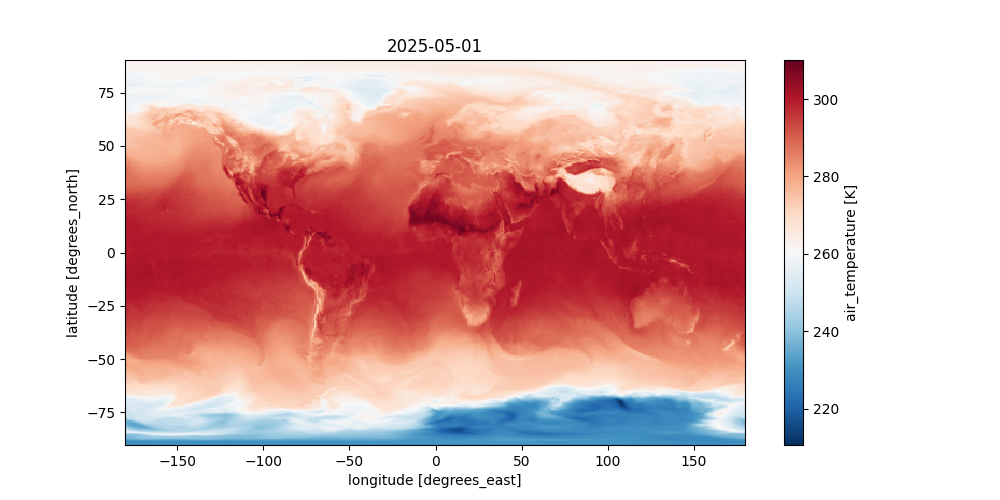

interactive(children=(SelectionSlider(description='Time', options=(('2025-05-01 00H', 0), ('2025-05-01 03H', 1…

<function __main__.plot_T(time_idx)>

In [53]:
widgets.interact(
    plot_T,
    time_idx=widgets.SelectionSlider(
        options=[(t.strftime("%Y-%m-%d %HH"), i) for i, t in enumerate(times)],
        description="Time",
        style={"description_width": "initial"}
    )
)

::::{admonition} Why `.compute()` first?
:class: tip
xarray lazily loads data from S3 — it only fetches what it needs, when 
it needs it. Calling `.compute()` loads the data into memory up front, 
so moving the slider is fast rather than triggering a new S3 request 
each time.
::::

# Summary

In this tutorial, you used `earthaccess` to find, access, and visualize 
NASA MERRA-2 data directly from the cloud without downloading any files. 
Here's what you did:

- **Authenticated** with NASA Earthdata Login using `earthaccess.login()`
- **Searched** for cloud-hosted MERRA-2 collections and granules using 
  keywords, spatial bounding boxes, and date ranges
- **Streamed** data directly from S3 into memory using `earthaccess.open()`
- **Opened** multi-file datasets with `xarray.open_mfdataset()` for 
  efficient lazy loading
- **Visualized** temperature at 500 hPa interactively across time using 
  `ipywidgets` and `matplotlib`

The same workflow — search, open, load, visualize — applies to any of 
the thousands of NASA datasets available on Earthdata Cloud.

::::{admonition} Next steps
:class: seealso
- Explore other MERRA-2 variables (e.g. wind, humidity) by replacing `T` 
  with another variable name from `ds`
- Try a different dataset by changing the `short_name` in `search_data`
::::